In [ ]:
from tabulate import tabulate
import os
import sys
import torch
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from utils import get_test_images, get_models_results, compare_plot_patches_models, compare_loss_plot

%load_ext autoreload
%autoreload 2

In [10]:
all_images = get_test_images()
print(all_images.keys())
print(all_images[5].keys())
print(all_images[5][2].keys())
print(len(all_images[5][2]['lr']), len(all_images[5][2]['hr']))

device = "cpu"

dict_keys([5, 14])
dict_keys([2, 3, 4])
dict_keys(['lr', 'hr'])
5 5


## Tablas

In [ ]:
models_name = ["nearest", "bilinear", "bicubic"]
set_numbers = [5, 14]
factors= [2, 4]
results1 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results1, headers="keys", tablefmt="fancy_grid", showindex=False))

In [ ]:
models_name = ["bicubic", "SRCNN", "FSRCNN", "FSRCA PS", "FSRCA"]
set_numbers = [5, 14]
factors= [2, 4]
results2 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results2, headers="keys", tablefmt="fancy_grid", showindex=False))

In [ ]:
models_name = ["bicubic", "SRCNN", "FSRCNN ft", "FSRCA PS ft", "FSRCA ft"]
set_numbers = [5, 14]
factors= [2, 4]
results3 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results3, headers="keys", tablefmt="fancy_grid", showindex=False))

In [24]:
models_name = ["SRCNN", "FSRCNN ft", "FSRCA PS ft", "FSRCA ft"]
set_numbers = [5, 14]
factors= [2, 4]
results4 = get_models_results(models_name, set_numbers, factors, device, time_test=10)
# print(tabulate(results4, headers="keys", tablefmt="fancy_grid", showindex=False))
print(results4)

Model weights not found at ../Results/Weights/SRCNN/srcnn_x4.pth.
Model weights not found at ../Results/Weights/FSRCA_PS/fsrca_ps_x4_ft.pth.
  Dataset  Factor                   SRCNN               FSRCNN ft  \
0    Set5       2  34.72/0.9496/0.043153s  34.54/0.9488/0.017607s   
1   Set14       2  30.70/0.8987/0.088267s  30.62/0.8988/0.036960s   
2    Set5       4                       -  28.63/0.8467/0.005065s   
3   Set14       4                       -  25.87/0.7403/0.008630s   

              FSRCA PS ft                FSRCA ft  
0  33.50/0.9413/0.052827s  34.64/0.9498/0.023147s  
1  29.94/0.8930/0.103142s  30.64/0.9000/0.050545s  
2                       -  28.81/0.8545/0.007202s  
3                       -  26.02/0.7464/0.012406s  


In [ ]:
models_name = ["SRCNN", "FSRCNN ft", "FSRCA PS ft", "FSRCA ft"]
# measure time 10 times for each model and average
set_numbers = [14]
factors= [2, 4]
result_arr = [get_models_results(models_name, set_numbers, factors, device) for _ in range(10)]

f2_time_run, f4_time_run = 0, 0
for name in models_name:
    for result in result_arr:
        data = result[name] # data is psnr/ssim/time
        f2_time_run += data['f2_time']
    print(f"Model: {name}, F2 Time: {f2_time_run/10:.2f}, F4 Time: {f4_time_run/10:.2f}")
    f2_time_run, f4_time_run = 0, 0

Model weights not found at ../Results/Weights/SRCNN/srcnn_x4.pth.
Model weights not found at ../Results/Weights/FSRCA_PS/fsrca_ps_x4_ft.pth.
  Dataset  Factor               SRCNN           FSRCNN ft         FSRCA PS ft  \
0    Set5       2  34.72/0.9496/0.37s  34.54/0.9488/0.19s  33.50/0.9413/0.34s   
1   Set14       2  30.70/0.8987/1.63s  30.62/0.8988/0.88s  29.94/0.8930/1.81s   
2    Set5       4                   -  28.63/0.8467/0.11s                   -   
3   Set14       4                   -  25.87/0.7403/0.53s                   -   

             FSRCA ft  
0  34.64/0.9498/0.18s  
1  30.64/0.9000/1.08s  
2  28.81/0.8545/0.10s  
3  26.02/0.7464/0.53s  


## Losses

### Factor 2

#### Sin FT

In [ ]:
loss = 'psnr_list'
models_names = ["srcnn", "fsrcnn", "fsrca", "fsrca_ps"]
colors = ["blue", "orange", "green", "red"]
fts = [False, False, False, False]
factor = 2
titles = ["SRCNN", "FSRCNN", "FSRCA", "FSRCA PS"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names,fts, factor, titles, colors, loss_label, device=device)

#### Con FT

In [ ]:
loss = 'psnr_list'
models_names = ["fsrcnn", "fsrca"]
fts = [True, True]
factor = 2
titles = ["FSRCNN FT", "FSRCA FT"]
colors = ["orange", "green"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names, fts, factor, titles, colors, loss_label, device=device)

### Factor 4

#### Sin FT

In [ ]:
loss = 'psnr_list'
models_names = ["fsrcnn", "fsrca",]
colors = ["orange", "green"]
fts = [False, False]
factor = 4
titles = ["FSRCNN", "FSRCA"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names,fts, factor, titles, colors, loss_label, device=device)

#### Con FT

In [ ]:
loss = 'psnr_list'
models_names = ["fsrcnn", "fsrca"]
fts = [True, True]
factor = 4
titles = ["FSRCNN FT", "FSRCA FT"]
colors = ["orange", "green"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names, fts, factor, titles, colors, loss_label, device=device)

## Imágenes

In [13]:
zoom_patches_args = {
    'zoom': 2,
    'patch_ratio': 0.25,
    'margin_ratio': 0.05,
    'thickness': 2
}

### Factor 2

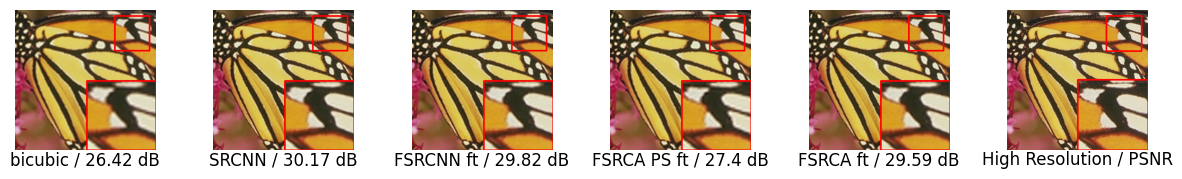

In [15]:
factor = 2
imgs_set = 5
set_dict = all_images[imgs_set][factor]
img_index = 2

models_names = ["bicubic",
                "SRCNN", 
                # "FSRCNN", 
                "FSRCNN ft",
                # "FSRCA",
                "FSRCA PS ft",
                "FSRCA ft"
                ]

compare_plot_patches_models(set_dict, img_index, factor, models_names, zoom_patches_args, device)

### Factor 4

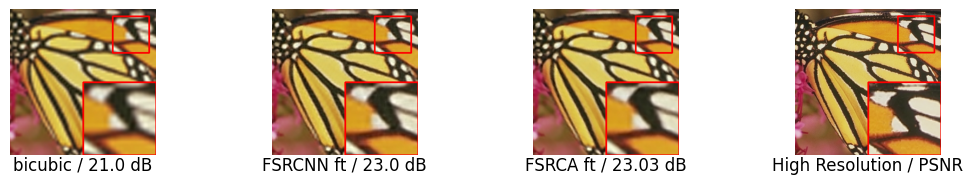

In [27]:
factor = 4
imgs_set = 5
set_dict = all_images[imgs_set][factor]
img_index = 2

models_names = ["bicubic",
                "FSRCNN ft",
                "FSRCA ft"
                ]

compare_plot_patches_models(set_dict, img_index, factor, models_names, zoom_patches_args, device)